# FeTa Pathological — Model Comparison

Compares four models evaluated on the **FeTa pathological** test subjects (n=11):

| Label | Model | Domain |
|---|---|---|
| CoNeMOS drawEM9-cond | CoNeMOS conditioned on DrawEM9 labels | cross-protocol |
| CoNeMOS FeTa-cond | CoNeMOS conditioned on FeTa labels | own-protocol |
| FeTa specialist | Specialist trained on FeTa | own-domain |
| dHCP specialist | Specialist trained on dHCP | cross-domain |

**Focus question**: how does CoNeMOS conditioned on DrawEM9 (dHCP protocol) labels perform on pathological FeTa subjects?

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import wilcoxon
from scipy.stats import false_discovery_control

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# FeTa has 7 structures; ch_08 (Hippocampus) is not annotated
STRUCT_NAMES = {
    1: 'CSF',
    2: 'Cortical GM',
    3: 'White Matter',
    4: 'Ventricles',
    5: 'Cerebellum',
    6: 'Deep GM',
    7: 'Brainstem',
}
FETA_STRUCTS = list(STRUCT_NAMES.values())
dice_cols = [f'dice_ch_{i:02d}' for i in range(1, 8)]
hd95_cols = [f'hd95_ch_{i:02d}' for i in range(1, 8)]
DICE_RENAME = {f'dice_ch_{i:02d}': n for i, n in STRUCT_NAMES.items()}
HD95_RENAME = {f'hd95_ch_{i:02d}': f'{n} HD95' for i, n in STRUCT_NAMES.items()}

# Okabe-Ito colorblind-safe palette
MODEL_PALETTE = {
    'CoNeMOS drawEM9-cond': '#E69F00',
    'CoNeMOS FeTa-cond':    '#56B4E9',
    'FeTa specialist':      '#009E73',
    'drawEM9 specialist':      '#D55E00',
}

In [86]:
RESULTS = {
    'CoNeMOS drawEM9-cond': '../eval_results/conemos_dhcp_cond_feta_pathological/results.csv',
    'CoNeMOS FeTa-cond':    '../eval_results/conemos_feta_cond_feta_pathological/results.csv',
    'FeTa specialist':      '../eval_results/feta_specialist_feta_pathological/results.csv',
    'drawEM9 specialist':      '../eval_results/dhcp_specialist_feta_pathological/results.csv',
}

dfs = {}
for name, path in RESULTS.items():
    d = pd.read_csv(path)
    for col in [f'hd95_ch_{i:02d}' for i in range(1, 9)] + ['mean_hd95']:
        if col not in d.columns:
            d[col] = float('nan')
    dfs[name] = d

subjects = sorted(dfs['CoNeMOS drawEM9-cond']['subject'].unique())
print(f'Subjects (n={len(subjects)}): {subjects}')

combined = pd.concat(
    [d.assign(model=name) for name, d in dfs.items()],
    ignore_index=True,
)
combined.head(3)

Subjects (n=11): ['sub-005', 'sub-008', 'sub-009', 'sub-011', 'sub-013', 'sub-014', 'sub-016', 'sub-018', 'sub-020', 'sub-024', 'sub-056']


,subject,protocol,conditioning,dice_ch_01,hd95_ch_01,dice_ch_02,hd95_ch_02,dice_ch_03,hd95_ch_03,dice_ch_04,...,dice_ch_06,hd95_ch_06,dice_ch_07,hd95_ch_07,dice_ch_08,hd95_ch_08,mean_dice,mean_hd95,pathological,model
0,sub-005,feta,drawem9_albert,0.255144,14.233323,0.338953,10.356158,0.617416,6.964194,0.720971,...,0.789609,2.598076,0.575170,4.387482,NaN,NaN,0.560875,6.358648,p,CoNeMOS drawEM9-cond
1,sub-008,feta,drawem9_albert,0.035344,16.355427,0.001085,24.259019,0.013015,20.571217,0.215342,...,0.583498,7.433034,0.032762,12.509996,NaN,NaN,0.139200,15.021566,p,CoNeMOS drawEM9-cond
2,sub-014,feta,drawem9_albert,0.819813,1.658312,0.732222,1.414214,0.891480,1.658312,0.858628,...,0.787438,2.828427,0.835776,1.500000,NaN,NaN,0.830903,1.930694,p,CoNeMOS drawEM9-cond


## 0 · Box + strip plot — overall performance

/tmp/ipykernel_344548/294113770.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_344548/294113770.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_344548/294113770.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_order, rotation=12, ha='right')


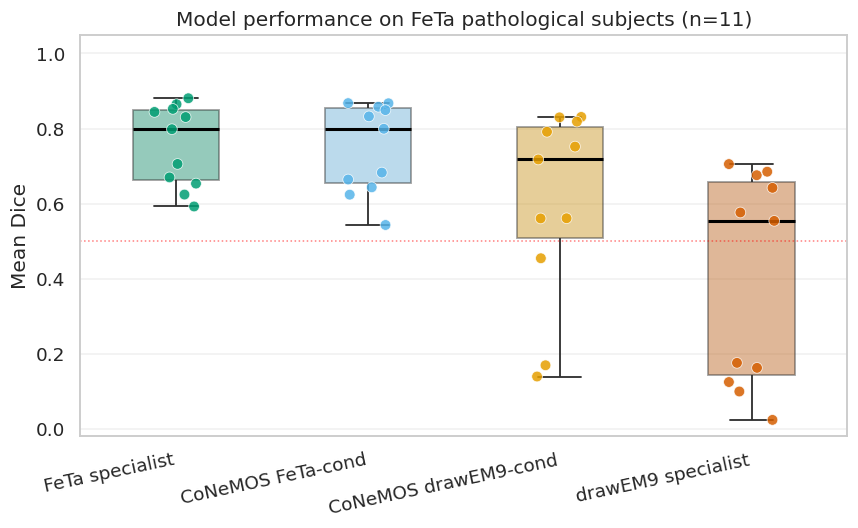

In [87]:
model_order = [
    'FeTa specialist',
    'CoNeMOS FeTa-cond',
    'CoNeMOS drawEM9-cond',
    'drawEM9 specialist',
]

long = combined[['subject', 'model', 'mean_dice']].copy()
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=long, x='model', y='mean_dice', order=model_order,
    palette=MODEL_PALETTE, width=0.45, linewidth=1.2,
    fliersize=0,
    boxprops=dict(alpha=0.45),
    medianprops=dict(linewidth=2, color='black'),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    ax=ax,
)
sns.stripplot(
    data=long, x='model', y='mean_dice', order=model_order,
    palette=MODEL_PALETTE, size=7, alpha=0.85, jitter=0.12,
    linewidth=0.5, edgecolor='white',
    ax=ax,
)

ax.set_xlabel('')
ax.set_ylabel('Mean Dice')
ax.set_ylim(-0.02, 1.05)
ax.set_xticklabels(model_order, rotation=12, ha='right')
ax.set_title('Model performance on FeTa pathological subjects (n=11)')
ax.axhline(0.5, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1 · Summary table

In [88]:
rows = []
for model_name, d in dfs.items():
    row = {'Model': model_name, 'N': len(d)}
    row['Mean Dice'] = f"{d['mean_dice'].mean():.3f} ± {d['mean_dice'].std():.3f}"
    row['Mean HD95'] = (f"{d['mean_hd95'].mean():.2f} ± {d['mean_hd95'].std():.2f}"
                        if d['mean_hd95'].notna().any() else 'n/a')
    for dc, name in DICE_RENAME.items():
        vals = d[dc].dropna()
        row[name] = f"{vals.mean():.3f}" if len(vals) else 'n/a'
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Model')
display(summary)

,N,Mean Dice,Mean HD95,CSF,Cortical GM,White Matter,Ventricles,Cerebellum,Deep GM,Brainstem
Model,,,,,,,,,,
CoNeMOS drawEM9-cond,11,0.602 ± 0.255,7.62 ± 8.45,0.500,0.481,0.671,0.611,0.591,0.727,0.634
CoNeMOS FeTa-cond,11,0.748 ± 0.118,3.01 ± 2.33,0.629,0.622,0.859,0.811,0.780,0.818,0.719
FeTa specialist,11,0.756 ± 0.108,2.91 ± 2.15,0.637,0.635,0.854,0.828,0.784,0.821,0.733
drawEM9 specialist,11,0.402 ± 0.279,12.34 ± 8.84,0.389,0.382,0.506,0.459,0.439,0.594,0.422


## 2 · Per-subject mean Dice (strip plot)

With only 11 subjects, showing individual points is more informative than box plots.

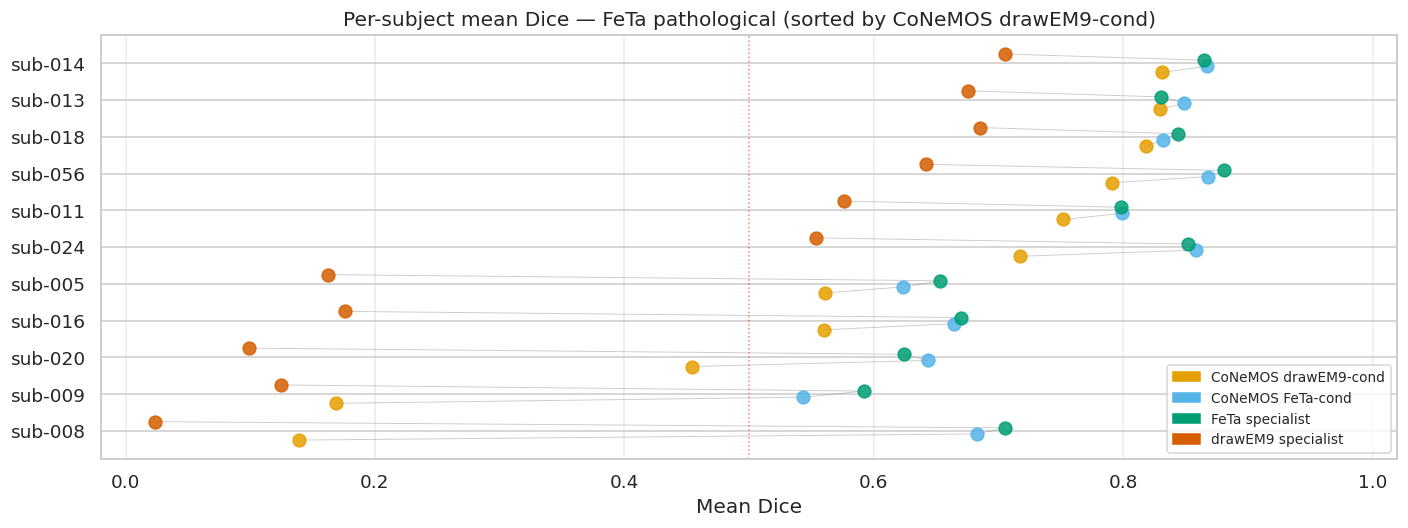

In [89]:
order = (
    dfs['CoNeMOS drawEM9-cond']
    .set_index('subject')['mean_dice']
    .sort_values()
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(13, 5))
y_pos = {subj: i for i, subj in enumerate(order)}
offsets = np.linspace(-0.25, 0.25, len(dfs))

for (model_name, d), offset in zip(dfs.items(), offsets):
    for subj in order:
        row = d[d.subject == subj]
        if len(row) == 0:
            continue
        val = row['mean_dice'].values[0]
        ax.scatter(
            val, y_pos[subj] + offset,
            color=MODEL_PALETTE[model_name], s=70, zorder=3, alpha=0.85,
            label=model_name if subj == order[0] else '',
        )

for subj in order:
    vals, ys = [], []
    for (model_name, d), offset in zip(dfs.items(), offsets):
        row = d[d.subject == subj]
        if len(row):
            vals.append(row['mean_dice'].values[0])
            ys.append(y_pos[subj] + offset)
    if vals:
        ax.plot(vals, ys, color='grey', linewidth=0.6, alpha=0.4, zorder=1)

ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels(order)
ax.set_xlabel('Mean Dice')
ax.set_xlim(-0.02, 1.02)
ax.set_title('Per-subject mean Dice — FeTa pathological (sorted by CoNeMOS drawEM9-cond)')
ax.axvline(0.5, color='red', linestyle=':', linewidth=1, alpha=0.5)
handles = [mpatches.Patch(color=c, label=m) for m, c in MODEL_PALETTE.items()]
ax.legend(handles=handles, loc='lower right', fontsize=9)
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

## 3 · Per-structure mean Dice comparison

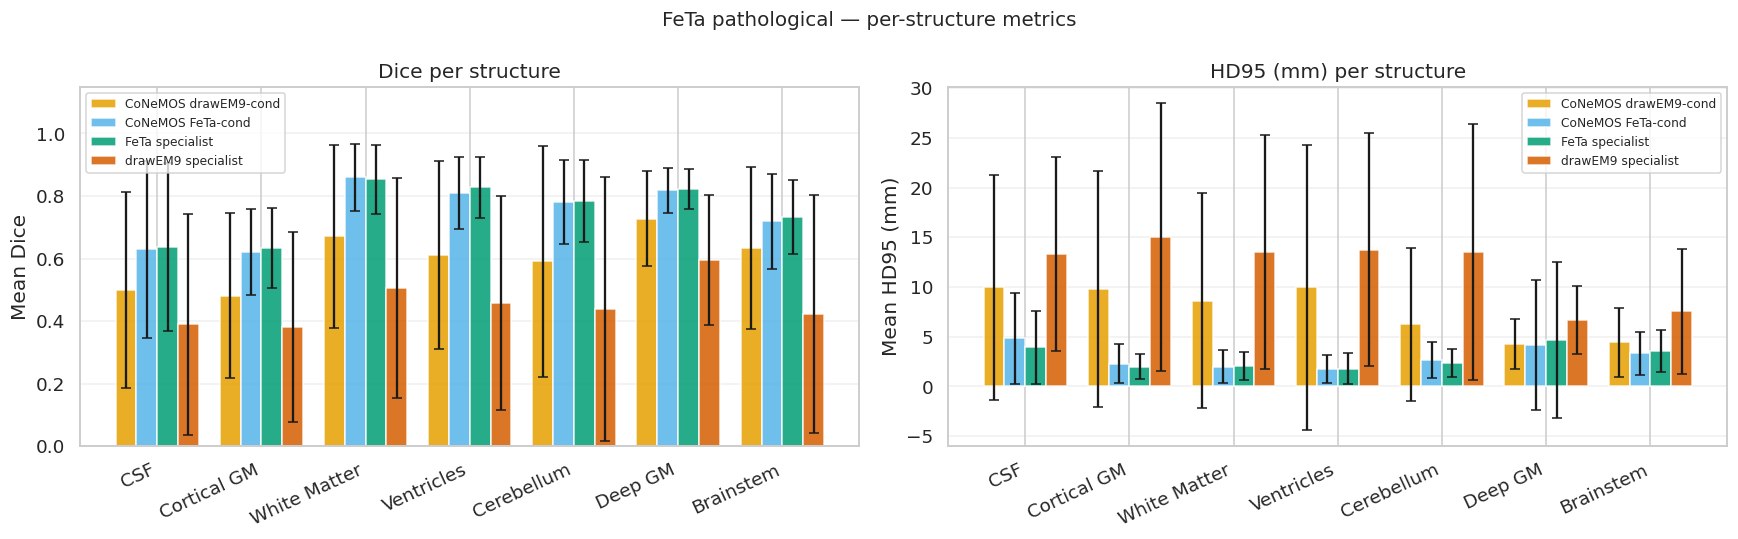

In [90]:
n_models = len(dfs)
x = np.arange(len(FETA_STRUCTS))
width = 0.8 / n_models

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, (model_name, d) in enumerate(dfs.items()):
    means_d = [d[dc].dropna().mean() for dc in dice_cols]
    stds_d  = [d[dc].dropna().std()  for dc in dice_cols]
    means_h = [d[hc].dropna().mean() for hc in hd95_cols]
    stds_h  = [d[hc].dropna().std()  for hc in hd95_cols]
    axes[0].bar(x + i * width, means_d, width, label=model_name,
                color=MODEL_PALETTE[model_name], yerr=stds_d, capsize=3, alpha=0.85)
    axes[1].bar(x + i * width, means_h, width, label=model_name,
                color=MODEL_PALETTE[model_name], yerr=stds_h, capsize=3, alpha=0.85)

for ax, title, ylabel, ylim in [
    (axes[0], 'Dice per structure', 'Mean Dice', (0, 1.15)),
    (axes[1], 'HD95 (mm) per structure', 'Mean HD95 (mm)', None),
]:
    ax.set_xticks(x + width * (n_models - 1) / 2)
    ax.set_xticklabels(FETA_STRUCTS, rotation=25, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    if ylim:
        ax.set_ylim(*ylim)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('FeTa pathological — per-structure metrics', fontsize=13)
plt.tight_layout()
plt.show()

## 4 · Per-subject Dice heatmaps (one per model)

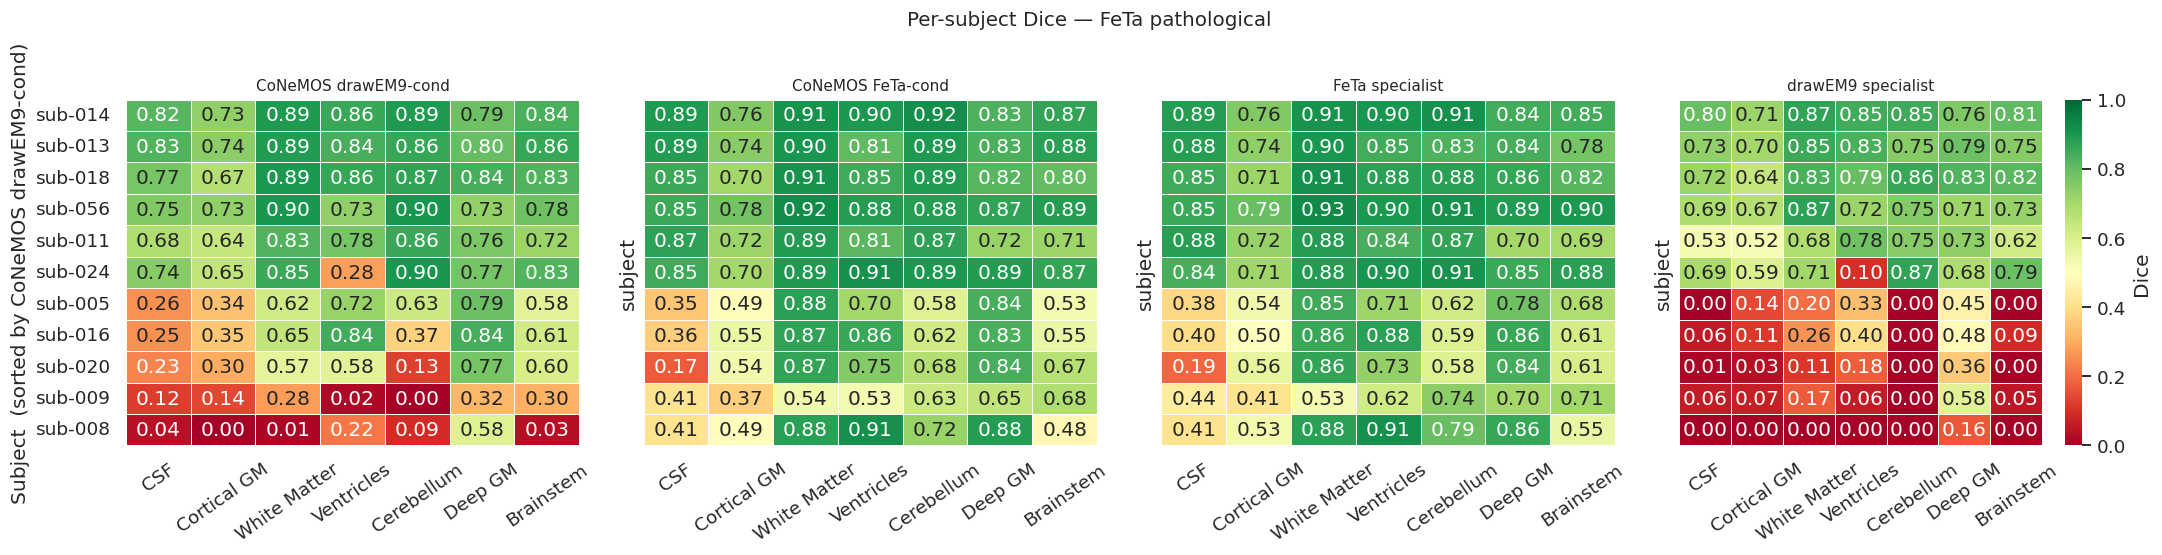

In [91]:
sort_order = (
    dfs['CoNeMOS drawEM9-cond']
    .set_index('subject')['mean_dice']
    .sort_values(ascending=False)
    .index.tolist()
)

fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True)

for ax, (model_name, d) in zip(axes, dfs.items()):
    heat = (
        d.rename(columns=DICE_RENAME)
         .set_index('subject')[FETA_STRUCTS]
         .reindex(sort_order)
    )
    sns.heatmap(
        heat, vmin=0, vmax=1, cmap='RdYlGn',
        linewidths=0.4, annot=True, fmt='.2f',
        cbar=(ax is axes[-1]),
        cbar_kws={'label': 'Dice'},
        ax=ax,
    )
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)

axes[0].set_ylabel('Subject  (sorted by CoNeMOS drawEM9-cond)')
plt.suptitle('Per-subject Dice — FeTa pathological', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5 · Δ Dice: CoNeMOS drawEM9-cond vs every other model

Positive = CoNeMOS drawEM9-cond is better.

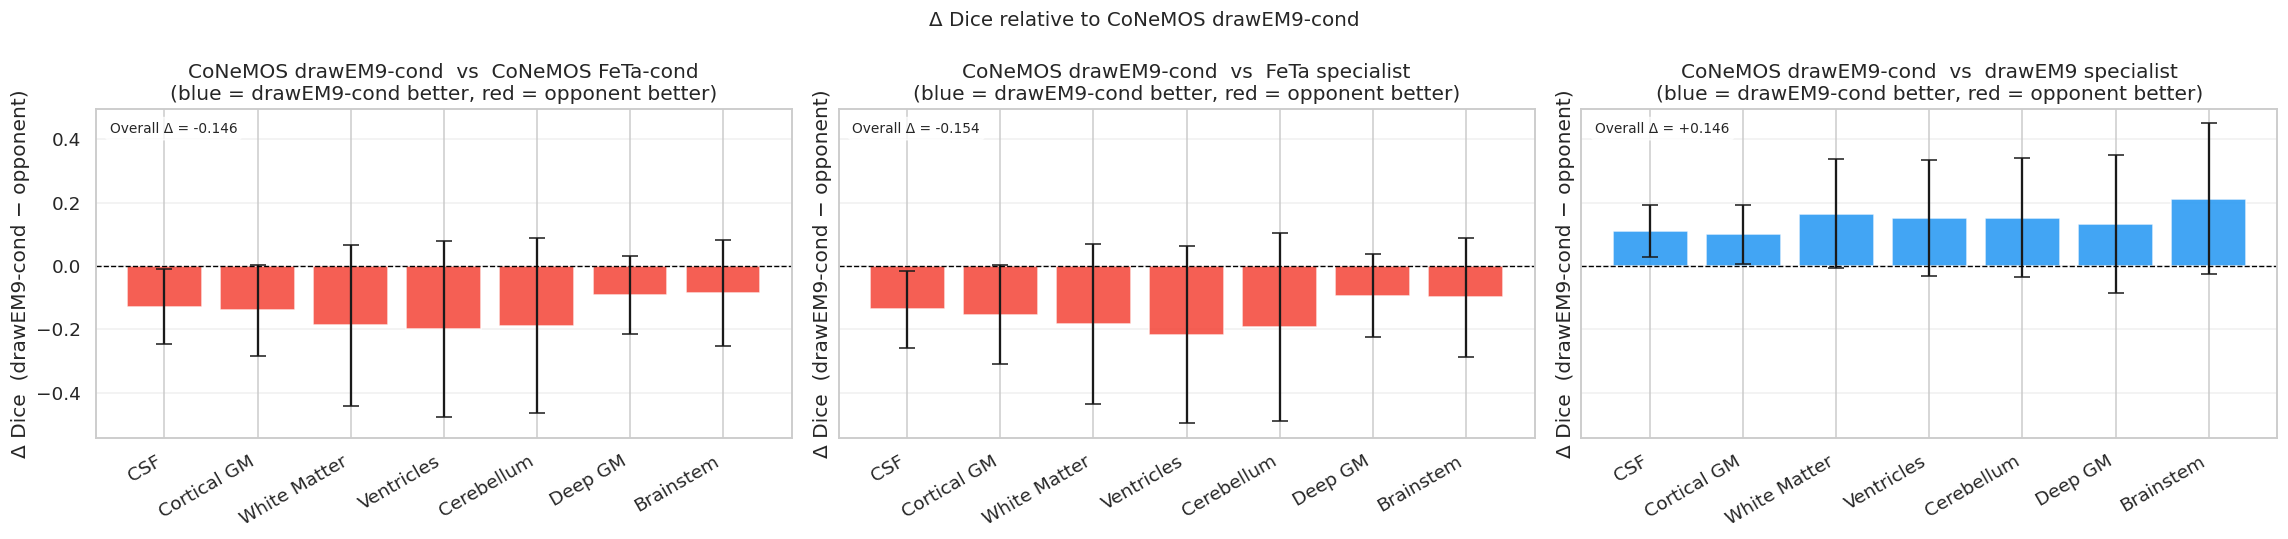

In [92]:
BASE = 'CoNeMOS drawEM9-cond'
comparisons = [m for m in dfs if m != BASE]

fig, axes = plt.subplots(1, len(comparisons), figsize=(7 * len(comparisons), 5), sharey=True)
if len(comparisons) == 1:
    axes = [axes]

for ax, comp in zip(axes, comparisons):
    base_d = dfs[BASE].rename(columns=DICE_RENAME).set_index('subject')
    comp_d = dfs[comp].rename(columns=DICE_RENAME).set_index('subject')
    shared = base_d.index.intersection(comp_d.index)

    delta = pd.DataFrame(index=shared)
    for s in FETA_STRUCTS:
        if s in base_d.columns and s in comp_d.columns:
            delta[s] = base_d.loc[shared, s].values - comp_d.loc[shared, s].values

    means  = delta.mean()
    stds   = delta.std()
    colors = ['#2196F3' if v > 0 else '#F44336' for v in means]

    ax.bar(range(len(FETA_STRUCTS)), means, color=colors, alpha=0.85, yerr=stds, capsize=5)
    ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
    ax.set_xticks(range(len(FETA_STRUCTS)))
    ax.set_xticklabels(FETA_STRUCTS, rotation=30, ha='right')
    ax.set_ylabel('Δ Dice  (drawEM9-cond − opponent)')
    ax.set_title(f'{BASE}  vs  {comp}\n(blue = drawEM9-cond better, red = opponent better)')
    ax.grid(True, axis='y', alpha=0.3)
    overall = delta.values[~np.isnan(delta.values)].mean()
    ax.text(0.02, 0.96, f'Overall Δ = {overall:+.3f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.suptitle(f'Δ Dice relative to {BASE}', fontsize=13)
plt.tight_layout()
plt.show()

## 6 · Radar plot — mean Dice per structure per model

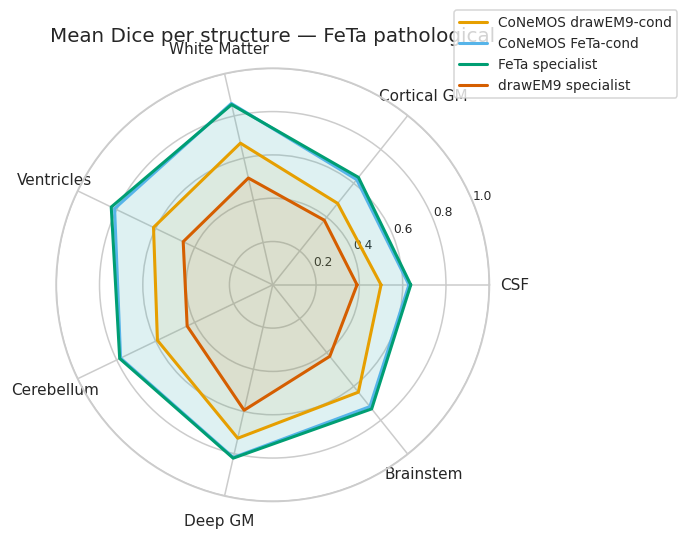

In [93]:
N      = len(FETA_STRUCTS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for model_name, d in dfs.items():
    vals = [d[dc].dropna().mean() for dc in dice_cols]
    color = MODEL_PALETTE[model_name]
    ax.plot(angles, vals + [vals[0]], color=color, linewidth=2, label=model_name)
    ax.fill(angles, vals + [vals[0]], color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(FETA_STRUCTS, size=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=8)
ax.set_title('Mean Dice per structure — FeTa pathological', size=13, pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

## 7 · Wilcoxon signed-rank tests (CoNeMOS drawEM9-cond vs others)

Per-structure paired test with BH-FDR correction.  
Note: n=11 subjects — results are indicative; interpret cautiously.

In [94]:
BASE = 'CoNeMOS drawEM9-cond'
sig_rows = []

for comp in [m for m in dfs if m != BASE]:
    base_d = dfs[BASE].set_index('subject')
    comp_d = dfs[comp].set_index('subject')
    shared = base_d.index.intersection(comp_d.index)

    p_vals = {}
    for dc, name in zip(dice_cols, FETA_STRUCTS):
        idx = base_d[dc].dropna().index.intersection(comp_d[dc].dropna().index).intersection(shared)
        if len(idx) < 5:
            p_vals[name] = np.nan
            continue
        a, b = base_d.loc[idx, dc].values, comp_d.loc[idx, dc].values
        try:
            _, p = wilcoxon(a, b)
        except Exception:
            p = np.nan
        p_vals[name] = p

    names_arr = list(p_vals.keys())
    p_arr = np.array([p_vals[n] for n in names_arr], dtype=float)
    valid = ~np.isnan(p_arr)
    p_adj = np.full(len(p_arr), np.nan)
    if valid.sum() > 1:
        p_adj[valid] = false_discovery_control(p_arr[valid], method='bh')
    else:
        p_adj[valid] = p_arr[valid]

    def stars(p):
        if np.isnan(p): return 'n/a'
        if p < 0.001:   return '***'
        if p < 0.01:    return '**'
        if p < 0.05:    return '*'
        return 'ns'

    for name, p_r, p_a in zip(names_arr, p_arr, p_adj):
        dc = dict(zip(FETA_STRUCTS, dice_cols))[name]
        sig_rows.append({
            'vs': comp, 'Structure': name,
            'Dice (base)': round(dfs[BASE][dc].mean(), 4),
            'Dice (comp)': round(dfs[comp][dc].mean(), 4),
            'Δ Dice':      round(dfs[BASE][dc].mean() - dfs[comp][dc].mean(), 4),
            'p_raw':       round(p_r, 4) if not np.isnan(p_r) else np.nan,
            'p_adj (BH)':  round(p_a, 4) if not np.isnan(p_a) else np.nan,
            'sig':         stars(p_a),
        })

sig_df = pd.DataFrame(sig_rows)
display(
    sig_df.sort_values(['vs', 'Structure'])
          .reset_index(drop=True)
          .style.applymap(
              lambda v: 'color: steelblue; font-weight: bold' if v in ('*','**','***') else '',
              subset=['sig']
          )
)
print('Significance (* p<0.05  ** p<0.01  *** p<0.001) after BH-FDR correction.')
print('Δ Dice = CoNeMOS drawEM9-cond − opponent  (positive → drawEM9-cond wins)')

/tmp/ipykernel_344548/86487457.py:52: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  sig_df.sort_values(['vs', 'Structure'])


,vs,Structure,Dice (base),Dice (comp),Δ Dice,p_raw,p_adj (BH),sig
0,CoNeMOS FeTa-cond,Brainstem,0.634200,0.719400,-0.085200,0.206100,0.206100,ns
1,CoNeMOS FeTa-cond,CSF,0.500100,0.629000,-0.128900,0.002000,0.004600,**
2,CoNeMOS FeTa-cond,Cerebellum,0.591100,0.779900,-0.188900,0.067400,0.078600,ns
3,CoNeMOS FeTa-cond,Cortical GM,0.480900,0.621700,-0.140800,0.001000,0.003400,**
4,CoNeMOS FeTa-cond,Deep GM,0.726700,0.818000,-0.091300,0.024400,0.034200,*
5,CoNeMOS FeTa-cond,Ventricles,0.611100,0.810600,-0.199500,0.024400,0.034200,*
6,CoNeMOS FeTa-cond,White Matter,0.671100,0.859200,-0.188100,0.001000,0.003400,**
7,FeTa specialist,Brainstem,0.634200,0.732800,-0.098600,0.174800,0.174800,ns
8,FeTa specialist,CSF,0.500100,0.637400,-0.137300,0.002000,0.004600,**
9,FeTa specialist,Cerebellum,0.591100,0.784500,-0.193400,0.042000,0.049000,*


Significance (* p<0.05  ** p<0.01  *** p<0.001) after BH-FDR correction.
Δ Dice = CoNeMOS drawEM9-cond − opponent  (positive → drawEM9-cond wins)


## 8 · Hard vs easy subjects

=== 4 hardest subjects for CoNeMOS drawEM9-cond ===


,CSF,Cortical GM,White Matter,Ventricles,Cerebellum,Deep GM,Brainstem,mean_dice
subject,,,,,,,,
sub-008,0.035,0.001,0.013,0.215,0.093,0.583,0.033,0.139
sub-009,0.124,0.140,0.276,0.017,0.002,0.319,0.305,0.169
sub-020,0.234,0.298,0.570,0.578,0.126,0.771,0.602,0.454
sub-016,0.255,0.350,0.648,0.845,0.371,0.841,0.613,0.560



=== 4 easiest subjects for CoNeMOS drawEM9-cond ===


,CSF,Cortical GM,White Matter,Ventricles,Cerebellum,Deep GM,Brainstem,mean_dice
subject,,,,,,,,
sub-056,0.755,0.734,0.901,0.732,0.904,0.729,0.784,0.791
sub-018,0.771,0.669,0.895,0.861,0.868,0.839,0.826,0.819
sub-013,0.827,0.739,0.887,0.839,0.860,0.797,0.860,0.830
sub-014,0.820,0.732,0.891,0.859,0.891,0.787,0.836,0.831


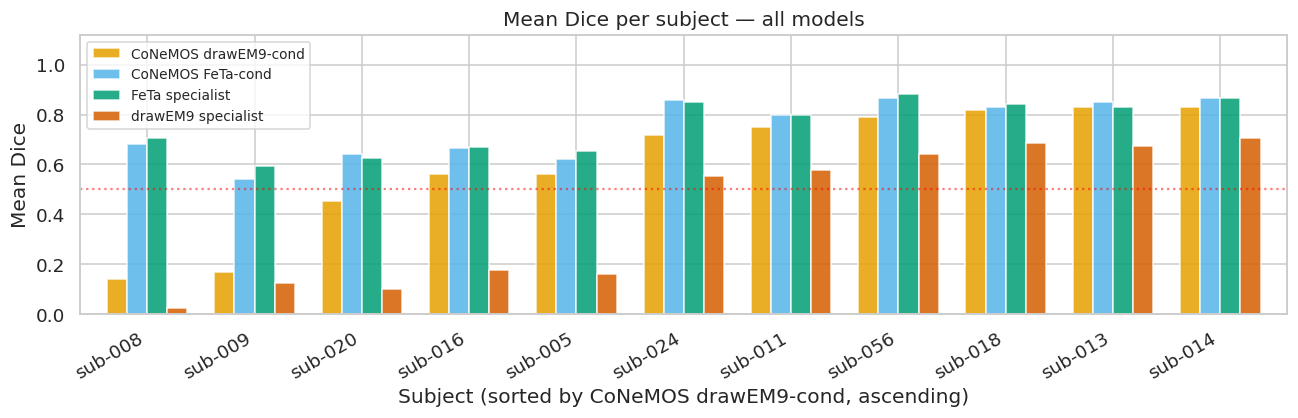

In [95]:
d_focus = dfs['CoNeMOS drawEM9-cond'].rename(columns=DICE_RENAME).copy()
d_focus = d_focus.set_index('subject').sort_values('mean_dice')

print('=== 4 hardest subjects for CoNeMOS drawEM9-cond ===')
display(d_focus[FETA_STRUCTS + ['mean_dice']].head(4).round(3))
print('\n=== 4 easiest subjects for CoNeMOS drawEM9-cond ===')
display(d_focus[FETA_STRUCTS + ['mean_dice']].tail(4).round(3))

model_means = pd.DataFrame({
    m: d.set_index('subject')['mean_dice'] for m, d in dfs.items()
}).reindex(d_focus.index)

fig, ax = plt.subplots(figsize=(12, 4))
model_means.plot(kind='bar', ax=ax,
                 color=[MODEL_PALETTE[m] for m in model_means.columns],
                 width=0.75, alpha=0.85)
ax.set_ylabel('Mean Dice')
ax.set_xlabel('Subject (sorted by CoNeMOS drawEM9-cond, ascending)')
ax.set_title('Mean Dice per subject — all models')
ax.set_ylim(0, 1.12)
ax.axhline(0.5, color='red', linestyle=':', alpha=0.5)
ax.legend(fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()